In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8')
%matplotlib inline

print("All imports successful")

All imports successful


In [3]:
# Define paths to each fault file
DATA_DIR = '../data/raw'

fault_files = {
    'NF'   : 'Preprocessed_No_failed.mat',
    'OP'   : 'Preprocessed_Disconnect_Phase_10_11_21_.mat',
    '2PSC' : 'Preprocessed_Short_between_two_phases_.mat',
    '1PSC' : 'Preprocessed_Test_Data_Short_phases_Ln_G_.mat',
    'REVD' : 'Preprocessed_Rotor_Current_Failed_R_.mat',
    'VREC' : 'Preprocessed_Test_Data_Rotor_Current_Faild.mat'
}

# Verify all files exist
for label, fname in fault_files.items():
    full_path = os.path.join(DATA_DIR, fname)
    exists = os.path.exists(full_path)
    print(f"{label}: {'✓ found' if exists else '✗ NOT FOUND'} — {fname}")

NF: ✓ found — Preprocessed_No_failed.mat
OP: ✓ found — Preprocessed_Disconnect_Phase_10_11_21_.mat
2PSC: ✓ found — Preprocessed_Short_between_two_phases_.mat
1PSC: ✓ found — Preprocessed_Test_Data_Short_phases_Ln_G_.mat
REVD: ✓ found — Preprocessed_Rotor_Current_Failed_R_.mat
VREC: ✓ found — Preprocessed_Test_Data_Rotor_Current_Faild.mat


In [4]:
# Load one file and inspect its structure
sample_path = os.path.join(DATA_DIR, fault_files['NF'])
mat = scipy.io.loadmat(sample_path)

# Print all keys and their types
print("Keys in .mat file:")
for key, value in mat.items():
    if not key.startswith('__'):
        print(f"  {key}: type={type(value)}, ", end='')
        if hasattr(value, 'shape'):
            print(f"shape={value.shape}, dtype={value.dtype}")
        else:
            print(f"value={value}")

Keys in .mat file:
  label_data: type=<class 'numpy.ndarray'>, shape=(329, 1), dtype=uint8
  train_data: type=<class 'numpy.ndarray'>, shape=(329, 10000, 9), dtype=float64


In [5]:
# Check label values for each fault file
print("Label distribution per fault file:")
print("-" * 40)

all_labels = {}
for label, fname in fault_files.items():
    mat = scipy.io.loadmat(os.path.join(DATA_DIR, fname))
    labels = mat['label_data'].flatten()
    unique, counts = np.unique(labels, return_counts=True)
    all_labels[label] = labels
    print(f"{label}: unique labels={unique}, counts={counts}, total={len(labels)}")

Label distribution per fault file:
----------------------------------------
NF: unique labels=[5], counts=[329], total=329
OP: unique labels=[1], counts=[703], total=703
2PSC: unique labels=[3], counts=[753], total=753
1PSC: unique labels=[4], counts=[767], total=767
REVD: unique labels=[2], counts=[518], total=518
VREC: unique labels=[0], counts=[322], total=322


In [6]:
# Check the 9 channels - what are they?
# Load one experiment and check value ranges per channel
mat = scipy.io.loadmat(os.path.join(DATA_DIR, fault_files['NF']))
data = mat['train_data']  # shape (329, 10000, 9)

print(f"Data shape: {data.shape}")
print(f"\nPer-channel statistics (averaged across all experiments):")
print(f"{'Channel':<10} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-" * 50)

for i in range(data.shape[2]):
    channel = data[:, :, i]
    print(f"Ch {i:<7} {channel.min():>10.3f} {channel.max():>10.3f} "
          f"{channel.mean():>10.3f} {channel.std():>10.3f}")

Data shape: (329, 10000, 9)

Per-channel statistics (averaged across all experiments):
Channel           Min        Max       Mean        Std
--------------------------------------------------
Ch 0          -72.297     71.864      0.061     49.789
Ch 1          -72.513     72.352     -0.139     49.912
Ch 2          -71.996     71.896      0.023     49.721
Ch 3           -0.234      0.227     -0.000      0.146
Ch 4           -0.233      0.220     -0.006      0.147
Ch 5           -0.228      0.232      0.000      0.148
Ch 6            0.349      0.550      0.457      0.033
Ch 7           -0.631      3.592      1.512      0.869
Ch 8           -1.032      1.072     -0.009      0.042


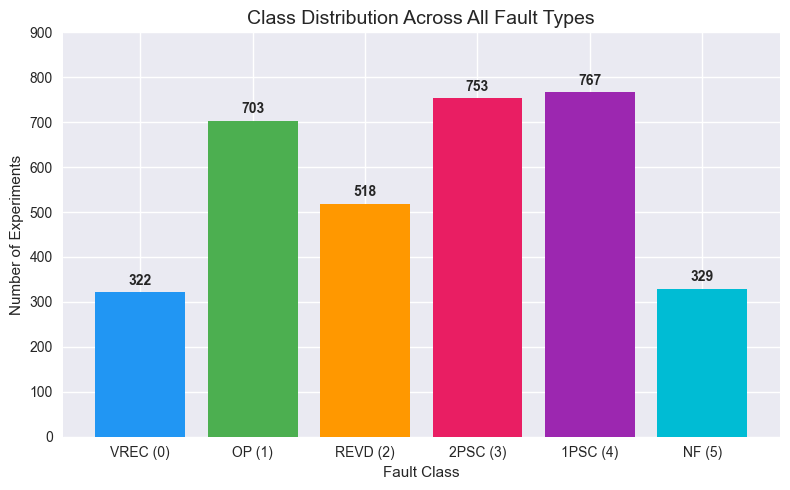


Total experiments: 3392
Most common class: 1PSC (4) (767)
Least common class: VREC (0) (322)
Imbalance ratio: 2.38x


In [7]:
# Visualise class balance
class_counts = {
    'VREC (0)': 322,
    'OP (1)':   703,
    'REVD (2)': 518,
    '2PSC (3)': 753,
    '1PSC (4)': 767,
    'NF (5)':   329
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_counts.keys(), class_counts.values(), 
              color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4'])

# Add count labels on top of bars
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontweight='bold')

ax.set_title('Class Distribution Across All Fault Types', fontsize=14)
ax.set_xlabel('Fault Class')
ax.set_ylabel('Number of Experiments')
ax.set_ylim(0, 900)

plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()

total = sum(class_counts.values())
print(f"\nTotal experiments: {total}")
print(f"Most common class: {max(class_counts, key=class_counts.get)} ({max(class_counts.values())})")
print(f"Least common class: {min(class_counts, key=class_counts.get)} ({min(class_counts.values())})")
print(f"Imbalance ratio: {max(class_counts.values())/min(class_counts.values()):.2f}x")

In [8]:
# Final channel map
channel_names = [
    'Stator Voltage A',    # Ch 0
    'Stator Voltage B',    # Ch 1
    'Stator Voltage C',    # Ch 2
    'Stator Current A',    # Ch 3
    'Stator Current B',    # Ch 4
    'Stator Current C',    # Ch 5
    'Rotor Current',       # Ch 6
    'Rotor Speed',         # Ch 7
]

# Ch 8 is fault trigger timestamp — excluded to prevent data leakage
SIGNAL_CHANNELS = list(range(8))  # only use channels 0-7
NUM_CHANNELS = len(SIGNAL_CHANNELS)

print(f"Using {NUM_CHANNELS} signal channels (dropping Ch 8 - fault trigger time)")
print(f"Channels: {SIGNAL_CHANNELS}")

Using 8 signal channels (dropping Ch 8 - fault trigger time)
Channels: [0, 1, 2, 3, 4, 5, 6, 7]


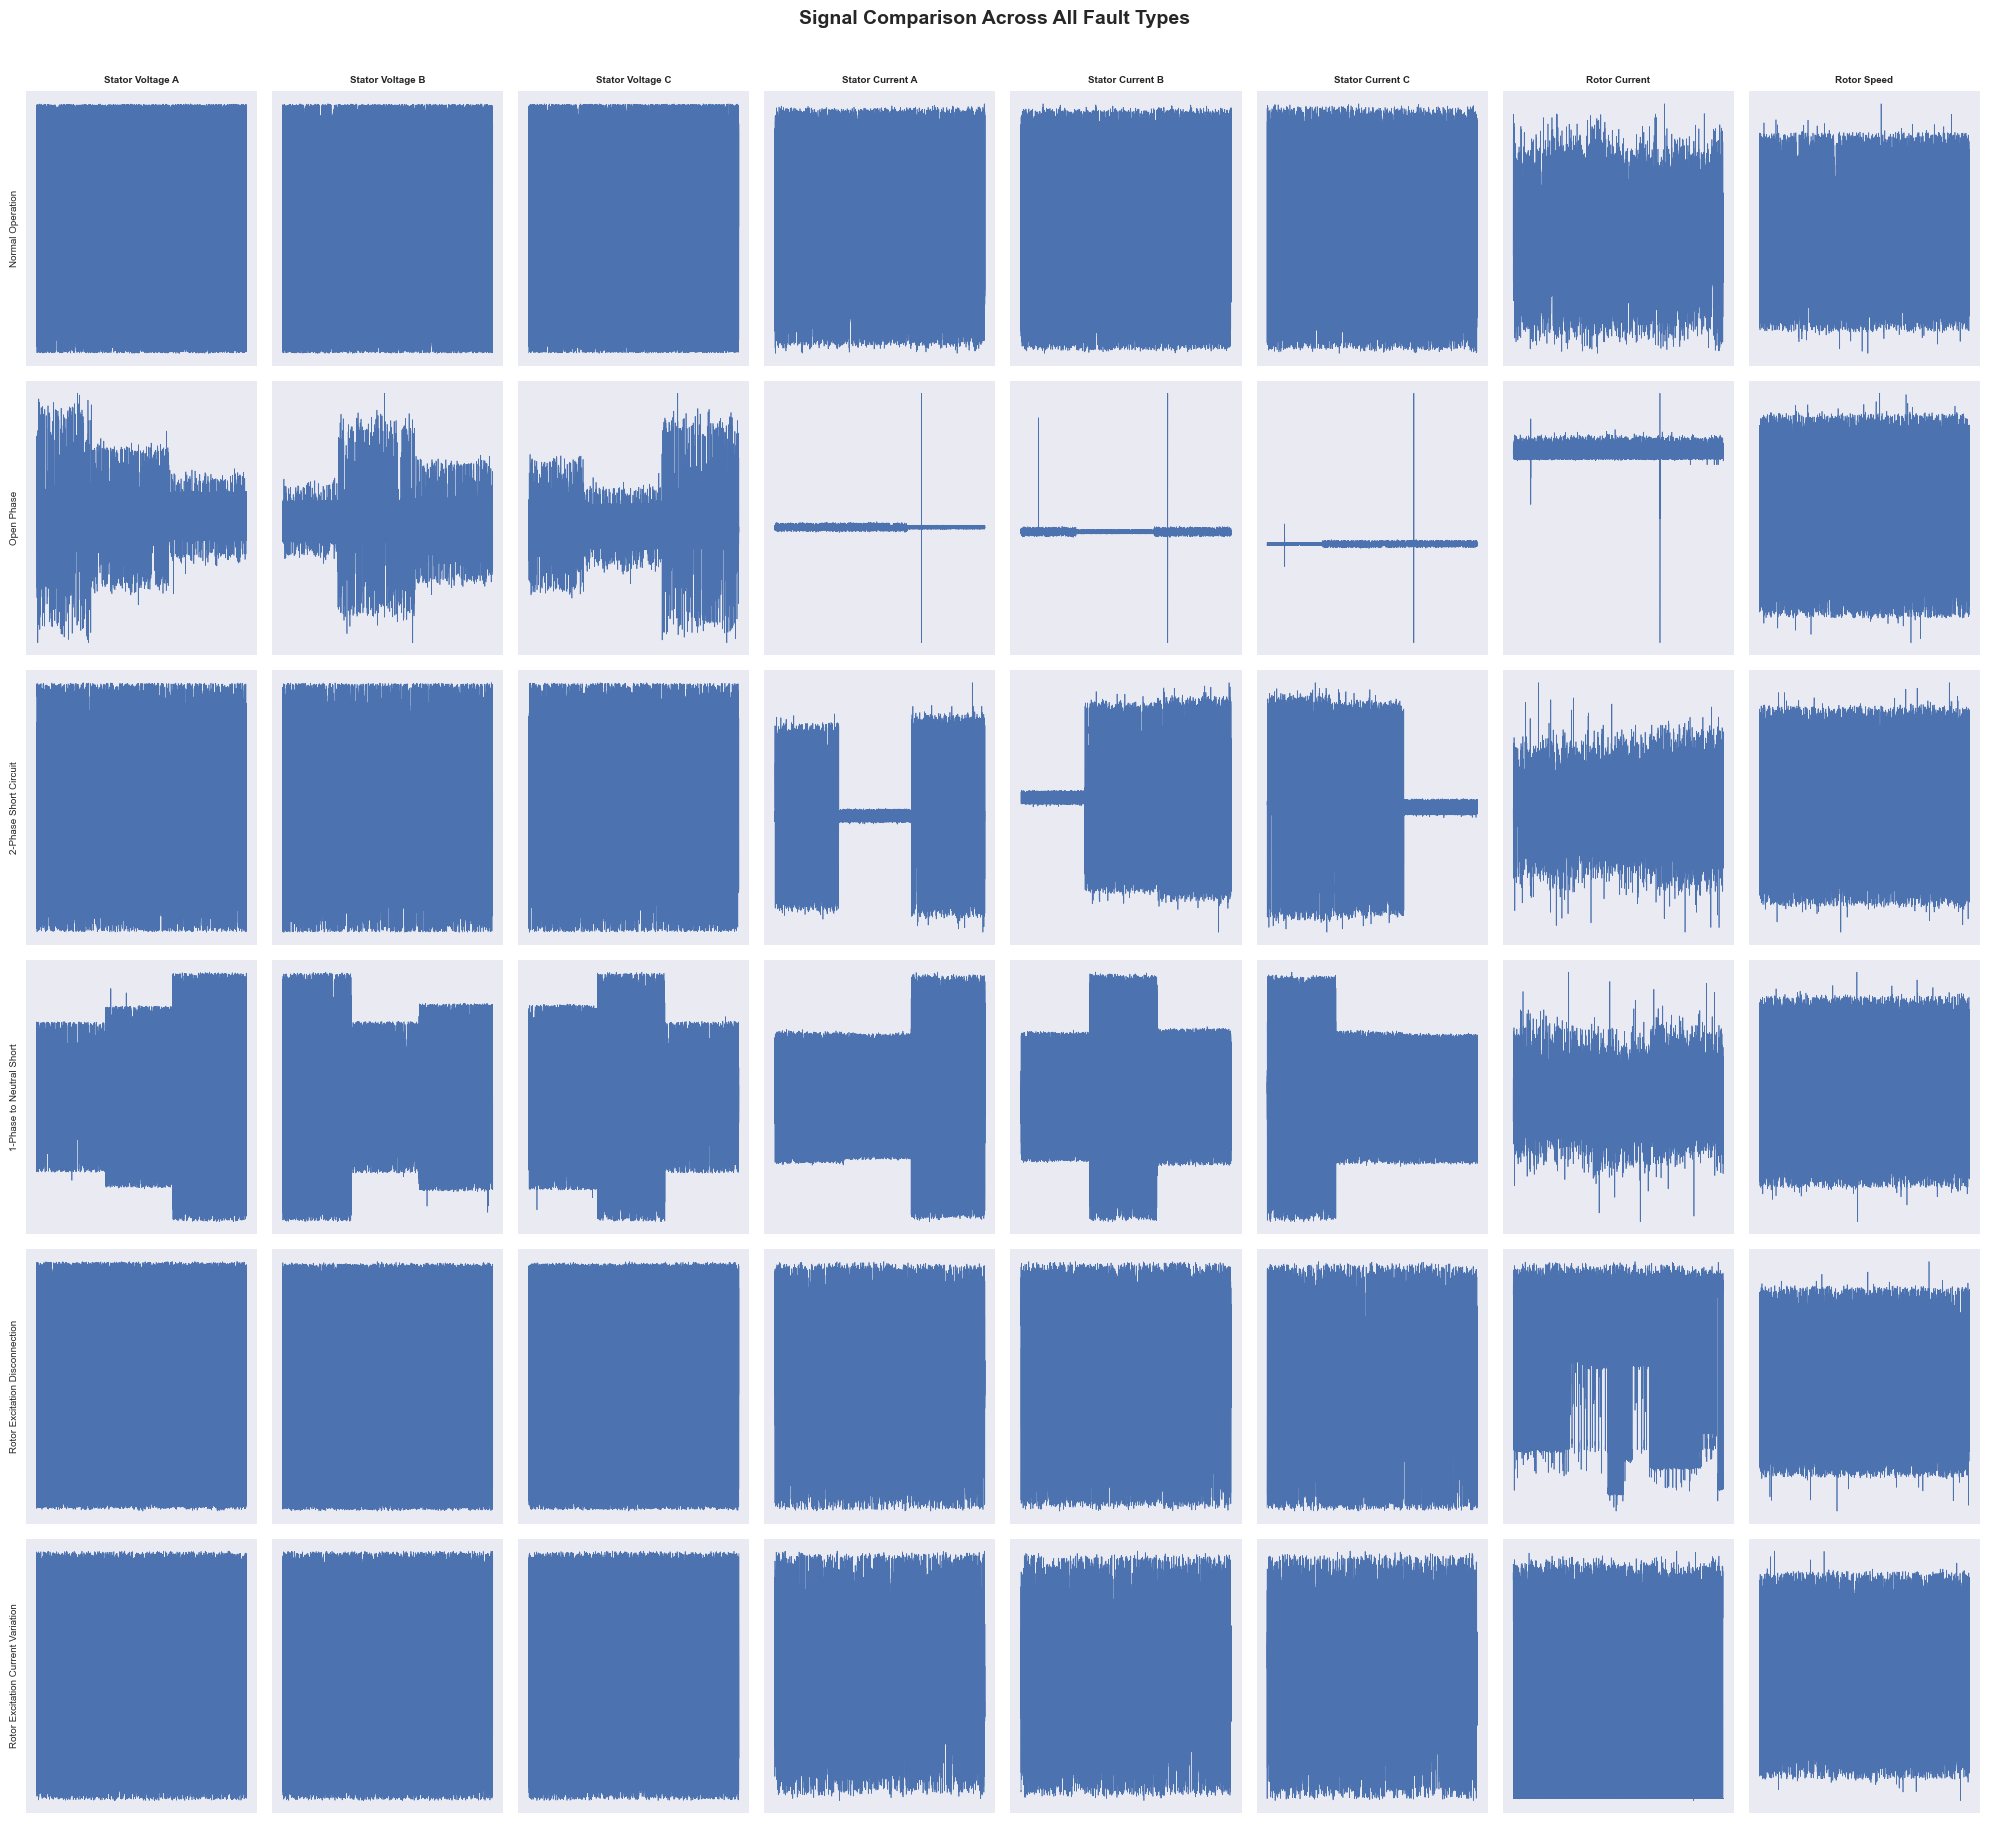

In [9]:
# Plot all channels for one experiment per fault type
fault_labels = {
    'NF'  : 'Normal Operation',
    'OP'  : 'Open Phase',
    '2PSC': '2-Phase Short Circuit',
    '1PSC': '1-Phase to Neutral Short',
    'REVD': 'Rotor Excitation Disconnection',
    'VREC': 'Rotor Excitation Current Variation'
}

fig, axes = plt.subplots(len(fault_labels), NUM_CHANNELS, 
                          figsize=(20, 18))

for row, (fault_key, fault_name) in enumerate(fault_labels.items()):
    mat = scipy.io.loadmat(os.path.join(DATA_DIR, fault_files[fault_key]))
    data = mat['train_data']
    
    # Pick first experiment
    experiment = data[0, :, :NUM_CHANNELS]  # shape (10000, 8)
    
    for col, ch_name in enumerate(channel_names):
        ax = axes[row, col]
        ax.plot(experiment[:, col], linewidth=0.5)
        
        # Only label edges to keep it clean
        if row == 0:
            ax.set_title(ch_name, fontsize=7, fontweight='bold')
        if col == 0:
            ax.set_ylabel(fault_name, fontsize=7, rotation=90, 
                         labelpad=5)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Signal Comparison Across All Fault Types', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/fault_signal_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## EDA Summary

**Dataset Structure:**
- 6 fault classes, 3392 total experiments
- Each experiment: 10,000 time points × 9 channels
- Channel 8 excluded (fault trigger timestamp — data leakage risk)
- 8 signal channels used: 3× stator voltage, 3× stator current, 
  rotor current, rotor speed

**Class Imbalance:**
- Imbalance ratio: 2.38x (1PSC: 767 vs VREC: 322)
- Will address with weighted loss function during training

**Key Observations:**
- Stator voltages range ~±72V
- Stator currents range ~±0.23A  
- Rotor current is DC (always positive: 0.35–0.55A)
- Rotor speed has periodic pattern (mechanical rotation)

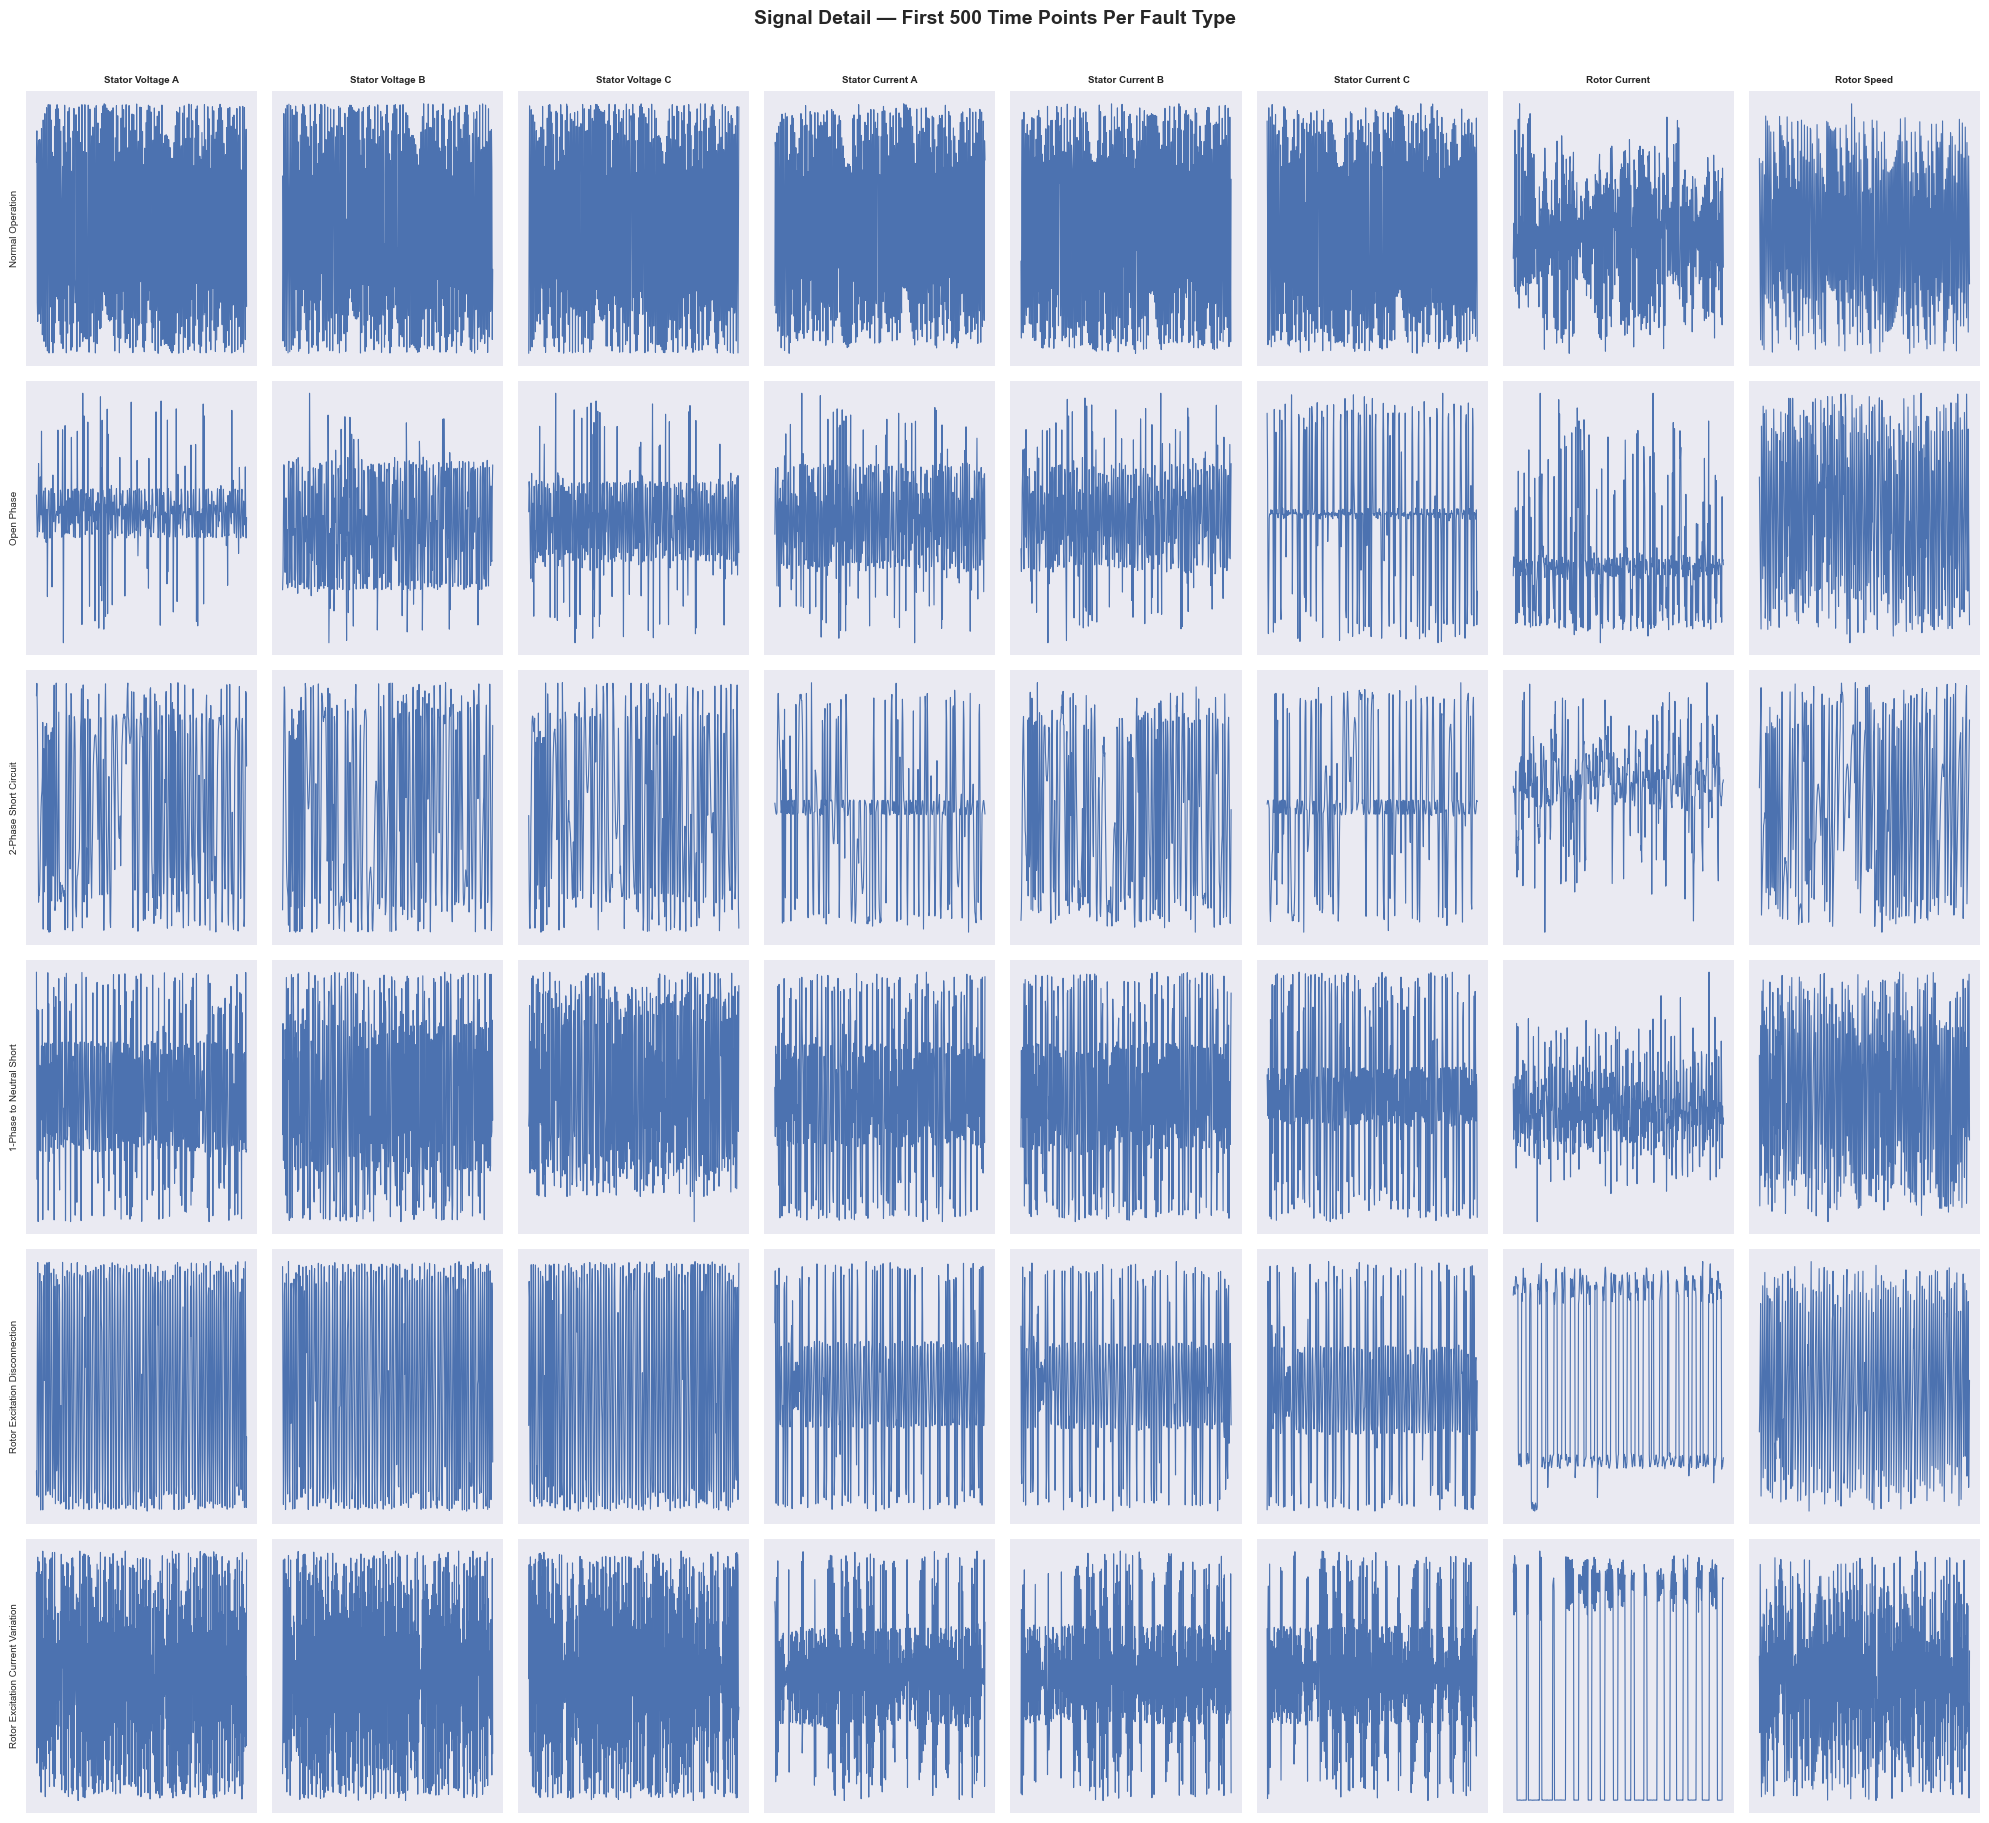

In [10]:
# Zoom into first 500 points to see actual waveform detail
fig, axes = plt.subplots(len(fault_labels), NUM_CHANNELS,
                          figsize=(20, 18))

ZOOM = 500  # show first 500 time points

for row, (fault_key, fault_name) in enumerate(fault_labels.items()):
    mat = scipy.io.loadmat(os.path.join(DATA_DIR, fault_files[fault_key]))
    data = mat['train_data']
    experiment = data[0, :ZOOM, :NUM_CHANNELS]

    for col, ch_name in enumerate(channel_names):
        ax = axes[row, col]
        ax.plot(experiment[:, col], linewidth=0.8)

        if row == 0:
            ax.set_title(ch_name, fontsize=7, fontweight='bold')
        if col == 0:
            ax.set_ylabel(fault_name, fontsize=7, rotation=90,
                         labelpad=5)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Signal Detail — First 500 Time Points Per Fault Type',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/fault_signal_zoomed.png',
            dpi=150, bbox_inches='tight')
plt.show()

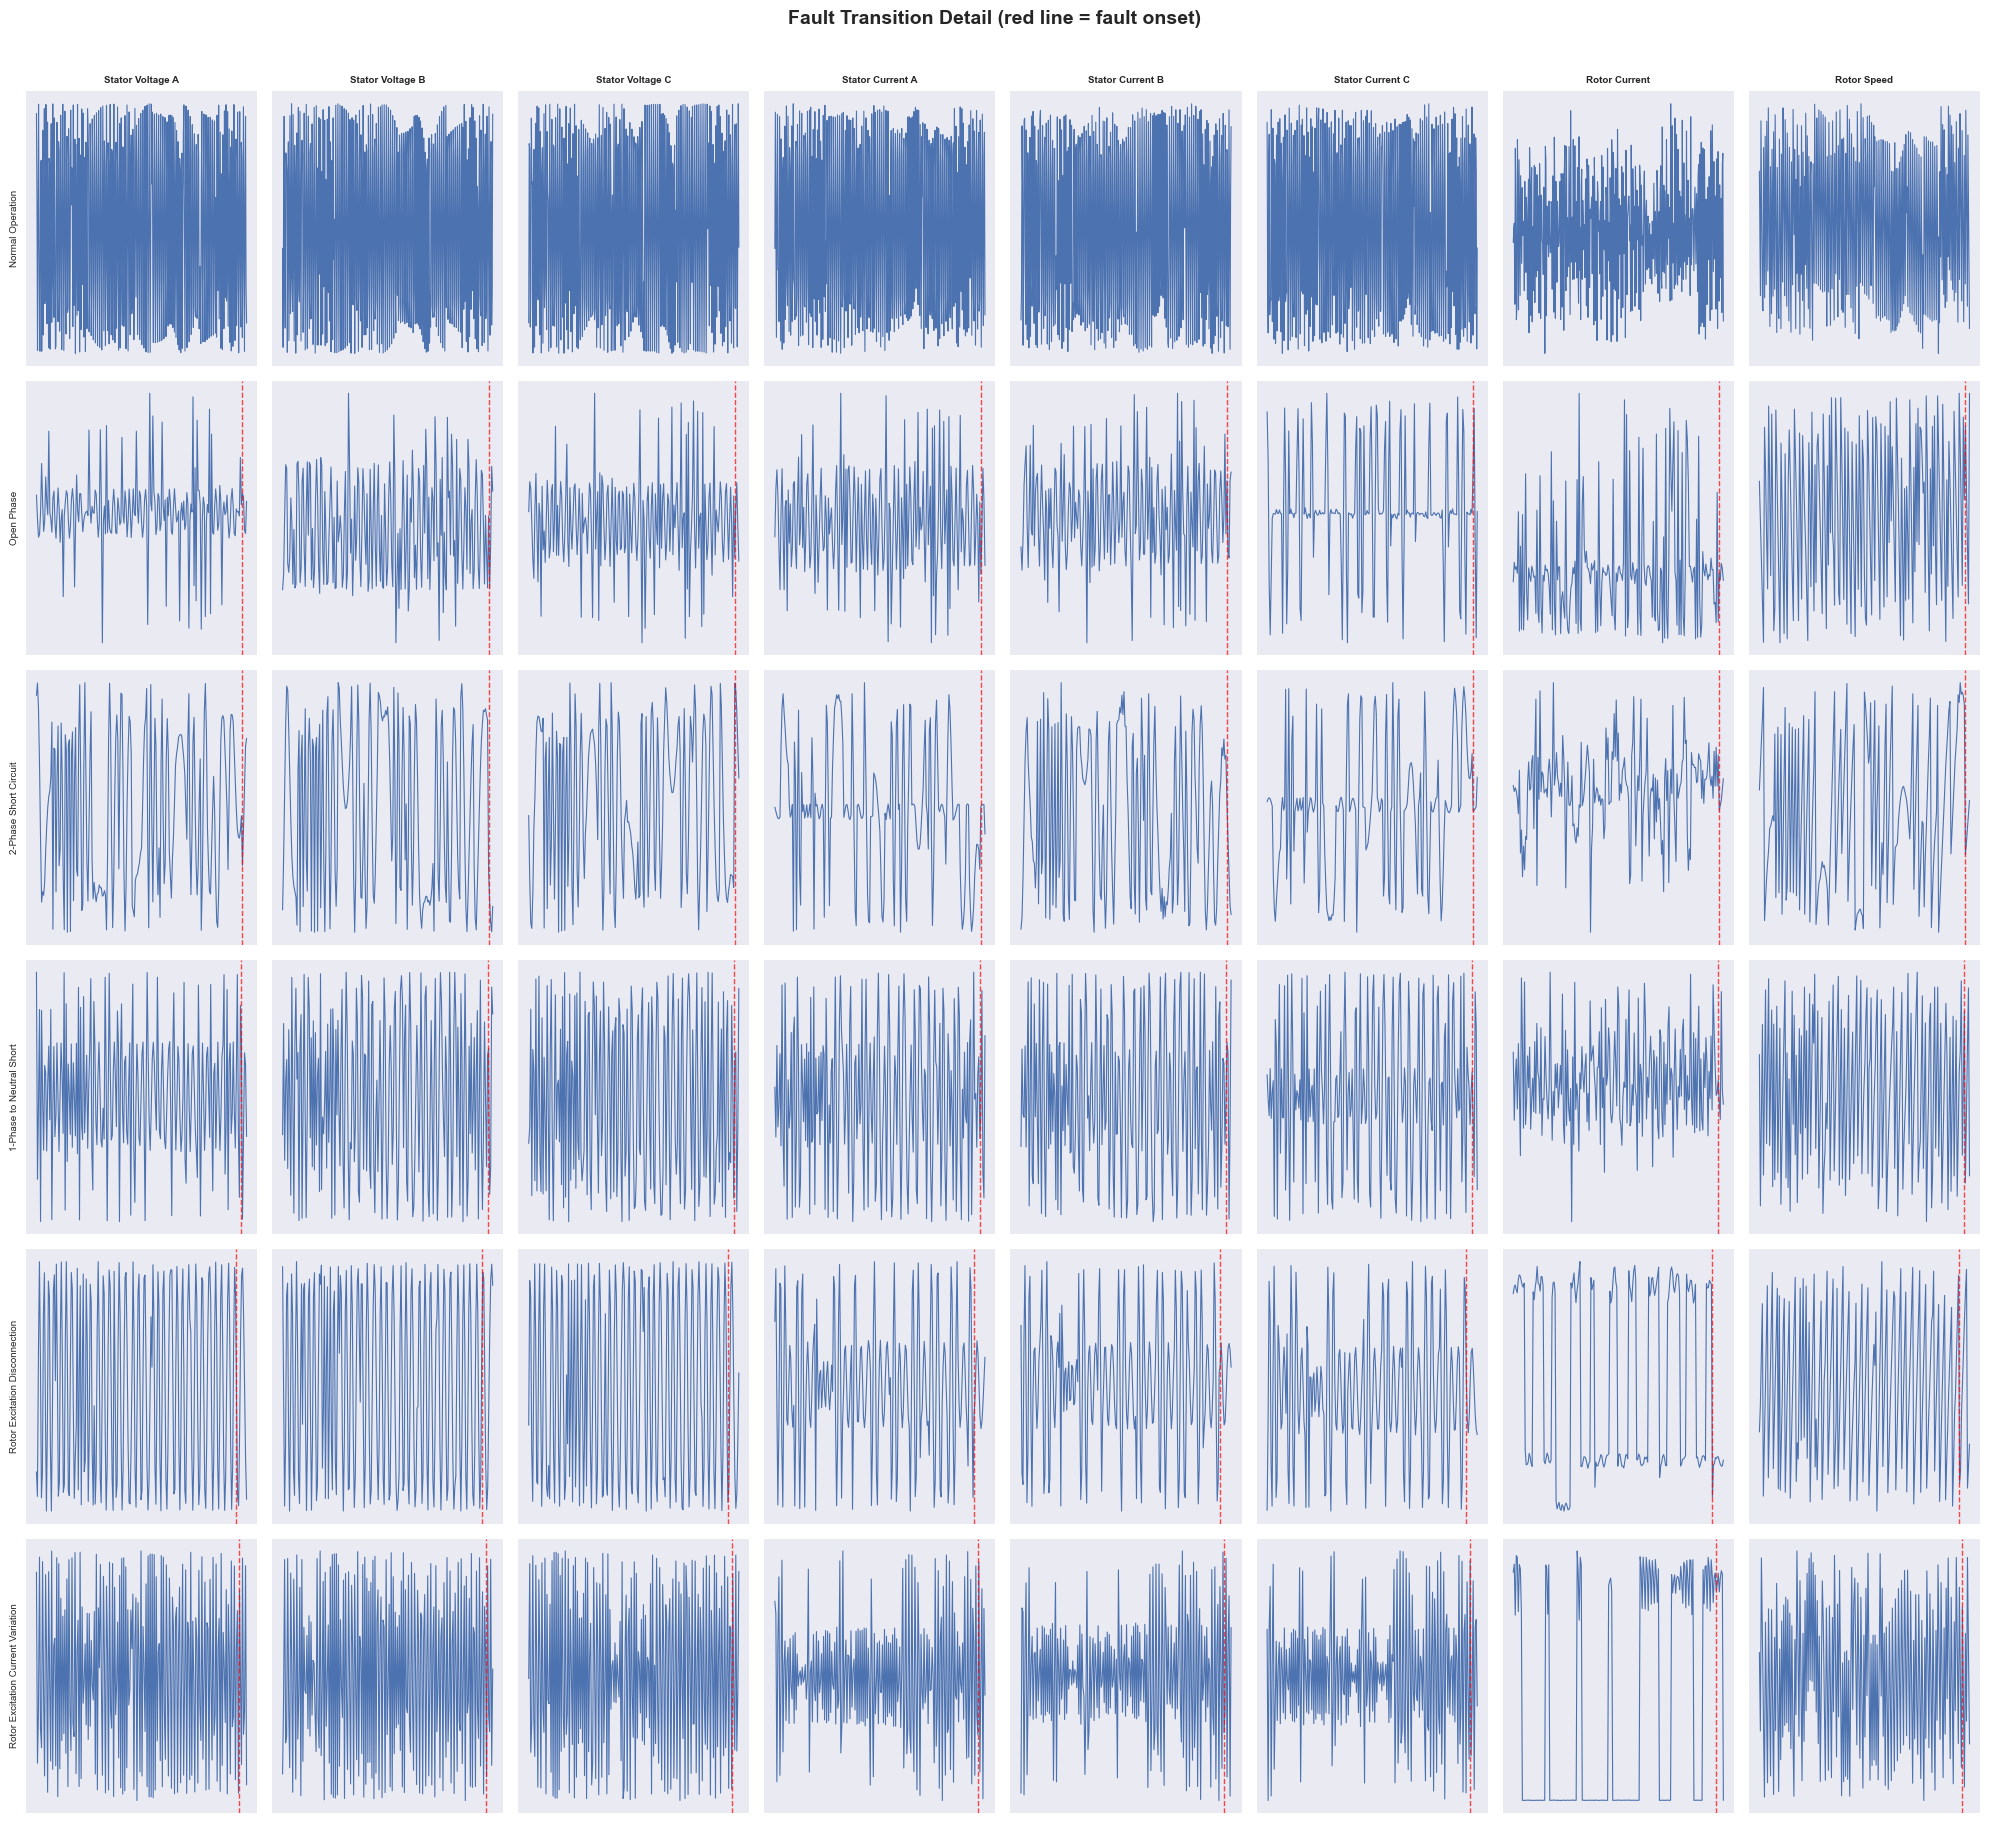

In [11]:
# Show the fault transition - 200 points before and after fault onset
# We know Ch 8 is the fault trigger time point, use it to find transition
fig, axes = plt.subplots(len(fault_labels), NUM_CHANNELS,
                          figsize=(20, 18))

WINDOW = 200  # points before and after fault

for row, (fault_key, fault_name) in enumerate(fault_labels.items()):
    mat = scipy.io.loadmat(os.path.join(DATA_DIR, fault_files[fault_key]))
    data = mat['train_data']     # (N, 10000, 9)
    fault_times = mat['train_data'][:, :, 8]  # Ch 8 = fault time

    # Find fault onset for first experiment
    experiment = data[0]
    fault_ch = experiment[:, 8]

    # Fault time is where Ch8 transitions from 0 to 1
    fault_onset = np.argmax(fault_ch > 0.5)

    # Handle NF case (no fault)
    if fault_onset == 0:
        fault_onset = 5000

    start = max(0, fault_onset - WINDOW)
    end = min(10000, fault_onset + WINDOW)
    segment = experiment[start:end, :NUM_CHANNELS]

    for col, ch_name in enumerate(channel_names):
        ax = axes[row, col]
        ax.plot(segment[:, col], linewidth=0.8)

        # Mark fault onset with vertical line
        if fault_key != 'NF':
            ax.axvline(x=WINDOW, color='red', linewidth=1,
                      linestyle='--', alpha=0.7)

        if row == 0:
            ax.set_title(ch_name, fontsize=7, fontweight='bold')
        if col == 0:
            ax.set_ylabel(fault_name, fontsize=7, rotation=90,
                         labelpad=5)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Fault Transition Detail (red line = fault onset)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/fault_transition.png',
            dpi=150, bbox_inches='tight')
plt.show()

NF: Ch8 min=-1.032, max=1.072, mean=-0.009, std=0.042
OP: Ch8 min=-1.135, max=8.310, mean=2.878, std=2.244
2PSC: Ch8 min=-0.786, max=5.861, mean=2.908, std=2.234
1PSC: Ch8 min=-0.883, max=5.594, mean=2.848, std=2.251
REVD: Ch8 min=-1.341, max=5.347, mean=2.908, std=2.240
VREC: Ch8 min=-1.032, max=9.766, mean=2.818, std=2.266


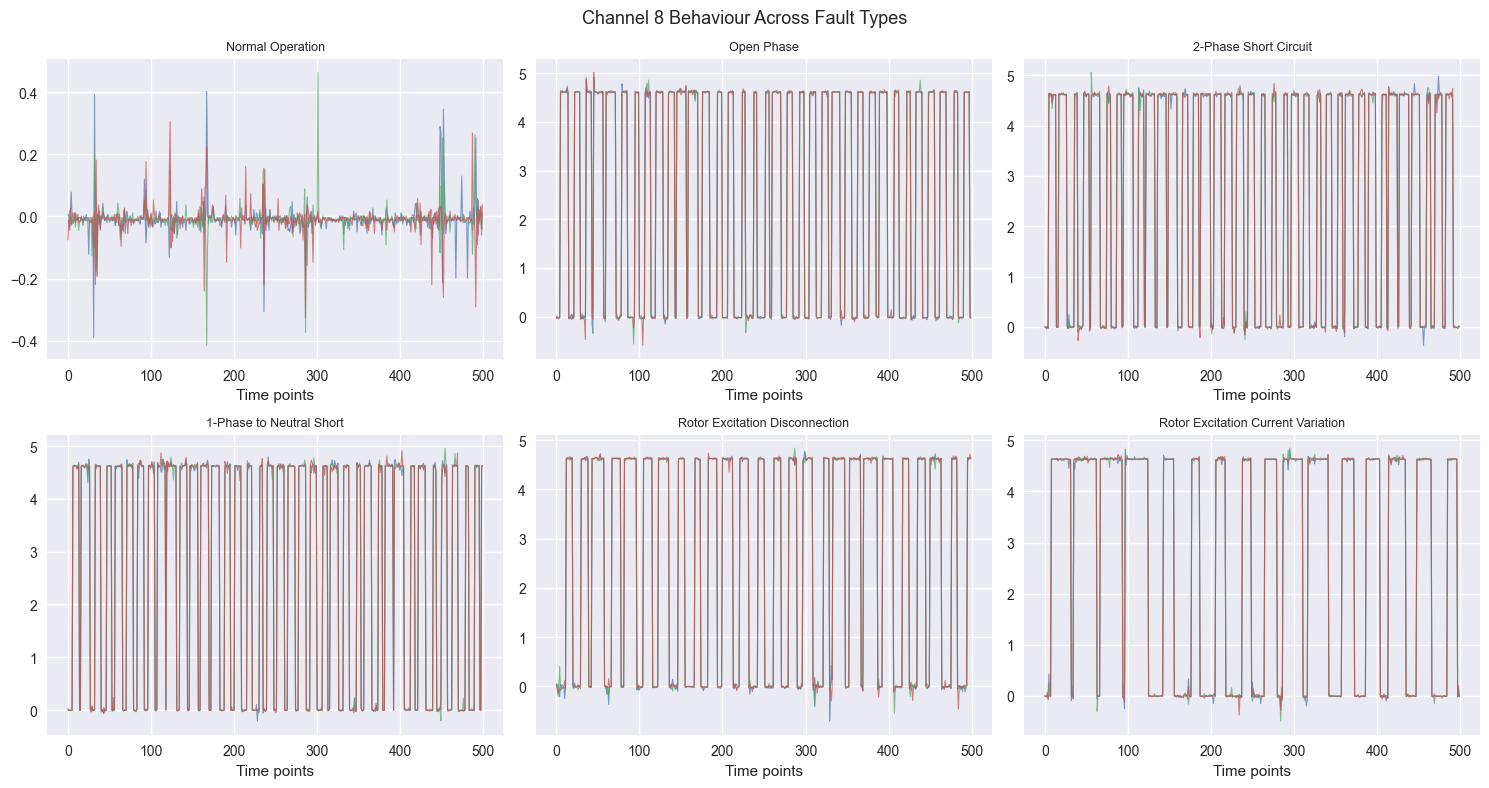

In [12]:
# Investigate Channel 8 properly across all fault types
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (fault_key, fault_name) in zip(axes.flat, fault_labels.items()):
    mat = scipy.io.loadmat(os.path.join(DATA_DIR, fault_files[fault_key]))
    data = mat['train_data']
    
    # Plot ch 8 for first 3 experiments
    for i in range(3):
        ch8 = data[i, :500, 8]
        ax.plot(ch8, linewidth=0.8, alpha=0.7, label=f'Exp {i}')
    
    ax.set_title(fault_name, fontsize=9)
    ax.set_xlabel('Time points')
    
    # Print stats
    ch8_all = data[:, :, 8]
    print(f"{fault_key}: Ch8 min={ch8_all.min():.3f}, "
          f"max={ch8_all.max():.3f}, "
          f"mean={ch8_all.mean():.3f}, "
          f"std={ch8_all.std():.3f}")

plt.suptitle('Channel 8 Behaviour Across Fault Types', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Check the label_data more carefully
for fault_key, fname in fault_files.items():
    mat = scipy.io.loadmat(os.path.join(DATA_DIR, fname))
    
    # Check all keys
    keys = [k for k in mat.keys() if not k.startswith('__')]
    print(f"\n{fault_key} keys: {keys}")
    
    # Check label_data in detail
    labels = mat['label_data'].flatten()
    print(f"  label_data unique values: {np.unique(labels)}")
    print(f"  label_data shape: {mat['label_data'].shape}")
    
    # Check train_data shape
    print(f"  train_data shape: {mat['train_data'].shape}")


NF keys: ['label_data', 'train_data']
  label_data unique values: [5]
  label_data shape: (329, 1)
  train_data shape: (329, 10000, 9)

OP keys: ['label_data', 'train_data']
  label_data unique values: [1]
  label_data shape: (703, 1)
  train_data shape: (703, 10000, 9)

2PSC keys: ['label_data', 'train_data']
  label_data unique values: [3]
  label_data shape: (753, 1)
  train_data shape: (753, 10000, 9)

1PSC keys: ['label_data', 'train_data']
  label_data unique values: [4]
  label_data shape: (767, 1)
  train_data shape: (767, 10000, 9)

REVD keys: ['label_data', 'train_data']
  label_data unique values: [2]
  label_data shape: (518, 1)
  train_data shape: (518, 10000, 9)

VREC keys: ['label_data', 'train_data']
  label_data unique values: [0]
  label_data shape: (322, 1)
  train_data shape: (322, 10000, 9)
